### Menentukan Nilai AUC dari ROC Curve

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import trapezoid
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression


In [14]:
# Load data & model
X, y = load_breast_cancer(return_X_y=True)
model = LogisticRegression(solver="newton-cholesky", random_state=0, max_iter=10000)
model.fit(X, y)

# Ambil skor prediksi (pakai probabilitas kelas positif)
scores = model.predict_proba(X)[:, 1]

In [15]:
# Thresholds 
thresholds = np.linspace(0, 1, 1000) # 0 sampe 1 dan mengambil 1000 titik angka

FPR = [] # Untuk simpan value false positif
TPR = [] # Untuk simpan value true positif

P = sum(y == 1) # jumlah label bernilai 1 untuk positif
N = sum(y == 0) # jumlah label bernilai 1 untuk negatif

for thresh in thresholds: # iterasi semua threshold
    TP = 0 # Variabel True Positive
    FP = 0 # Variabel True Negative 
    for i in range(len(scores)):
        if scores[i] >= thresh:
            if y[i] == 1:
                TP += 1 # Menjumlahkan setiap true positif
            else:
                FP += 1 # Menjumlahkan setiap true negatif
    TPR.append(TP / P) # TPR (True Positive Rate) = TP dibagi jumlah seluruh positif. Artinya: seberapa banyak yang positif berhasil ditangkap
    FPR.append(FP / N) # FPR (False Positive Rate) = FP dibagi jumlah seluruh negatif. Artinya: berapa banyak negatif yang salah dikira positif


AUC Manual: 0.9947
AUC scikit-learn: 0.9947


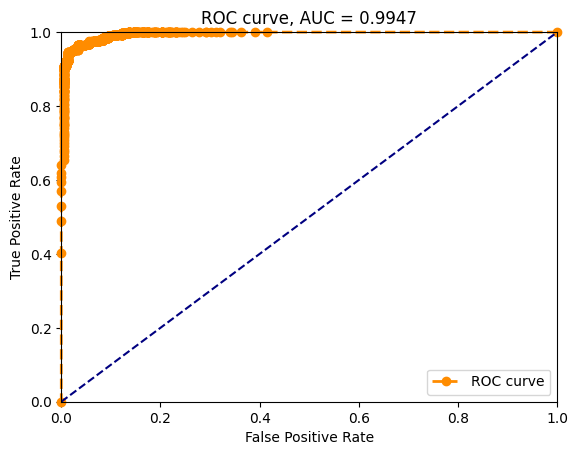

In [16]:
# Hitung AUC Manual
auc_manual = -1 * np.trapezoid(TPR, FPR) # menghitung luas di bawah kurva dari titik-titik (x, y) menggunakan metode trapesium.
print(f"AUC Manual: {auc_manual:.4f}")

from sklearn.metrics import roc_auc_score

auc_sklearn = roc_auc_score(y, scores)
print(f"AUC scikit-learn: {auc_sklearn:.4f}")

plt.plot(FPR, TPR, linestyle='--', marker='o', color='darkorange', lw = 2, label='ROC curve', clip_on=False)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve, AUC = %.4f'%auc_manual)
plt.legend(loc="lower right")
plt.savefig('AUC_example.png')
plt.show()